In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
train_dir = "../dataset/BrainTumorMRI/Training"
test_dir = "../dataset/BrainTumorMRI/Testing"

In [14]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


In [15]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1600 files belonging to 4 classes.


In [16]:
class_names = train_dataset.class_names

print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [17]:
for images, labels in train_dataset.take(1):

    print(images.shape)

    print(labels.shape)

(32, 224, 224, 3)
(32,)


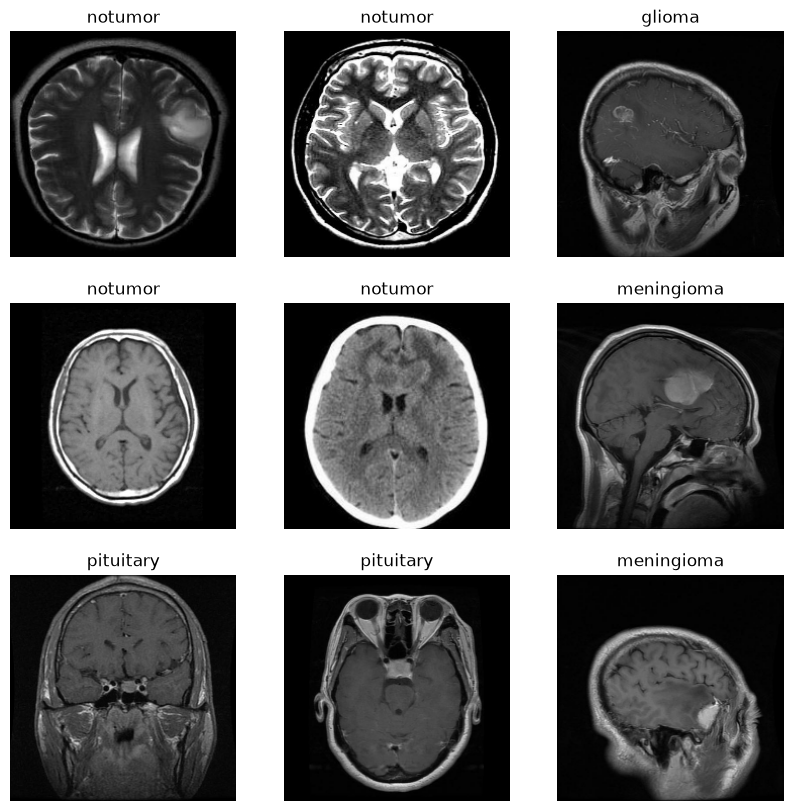

In [18]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [19]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [20]:
normalized_train = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

normalized_test = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [21]:
for images, labels in normalized_train.take(1):

    print(images[0].numpy().min())

    print(images[0].numpy().max())

0.0
0.8927943


In [22]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1)

])

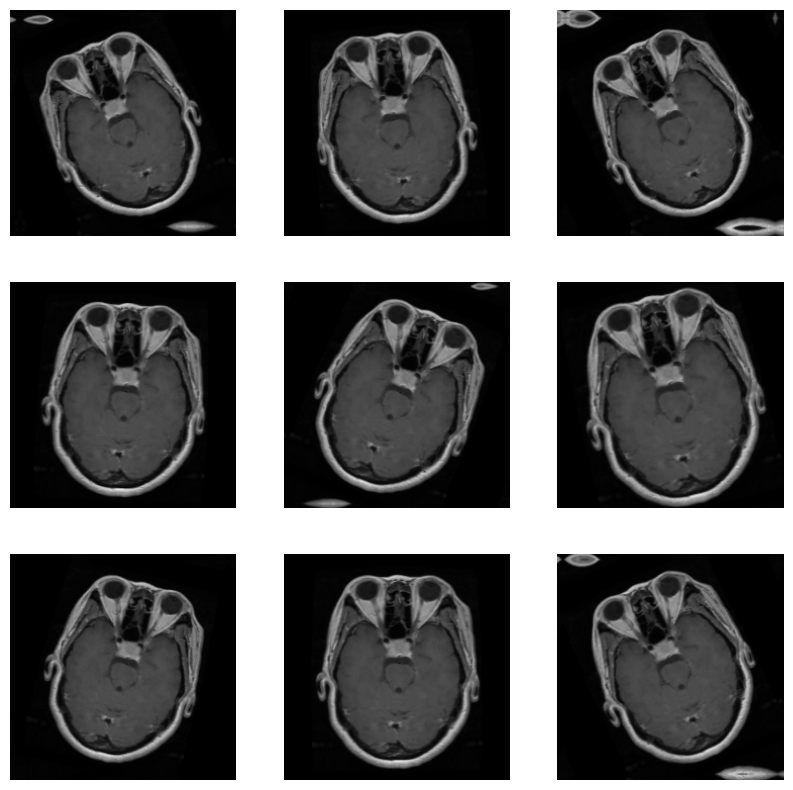

In [23]:
for images, labels in train_dataset.take(1):

    plt.figure(figsize=(10,10))

    first_image = images[0]

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        augmented = data_augmentation(
            tf.expand_dims(first_image,0)
        )

        plt.imshow(
            augmented[0].numpy().astype("uint8")
        )

        plt.axis("off")

plt.show()

In [24]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)

validation_dataset = validation_dataset.prefetch(AUTOTUNE)

test_dataset = test_dataset.prefetch(AUTOTUNE)